# LoRA from Scratch — No Libraries, Just Math

## What this notebook does
We implement **Low-Rank Adaptation (LoRA)** using nothing but PyTorch tensors.  
No `peft`, no `transformers`, no magic wrappers. Just the raw matrix math.

By the end you will:
1. Understand **why** full fine-tuning is wasteful
2. See **exactly** how LoRA's matrix decomposition works (with pictures)
3. Build a working `LoRALinear` layer from scratch
4. Inject it into a real neural network
5. Compare memory usage: Full Fine-Tune vs LoRA
6. Train and merge LoRA weights back

---

## The Analogy

Imagine you own a **1,000-page textbook** (the pretrained model).  
You need to adapt it for a new course.  

- **Full fine-tuning** = Rewriting every page. Expensive. Slow.  
- **LoRA** = Adding a small **sticky-note booklet** (say 20 pages) that contains only the corrections. The original book stays untouched. You carry just the sticky notes.

That's LoRA. Instead of updating a giant weight matrix $W$ directly, we learn a tiny correction $\Delta W = B \times A$ where $B$ and $A$ are much smaller matrices.

## Step 0: Setup
We only need PyTorch and matplotlib. That's it.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import copy

# Use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.9.0+cu126


---
## Step 1: Why Full Fine-Tuning is Expensive

Let's build a simple model and see how many parameters it has.  
In a real LLM, these numbers are **billions**.

In [2]:
class SimpleMLP(nn.Module):
    """A toy model to demonstrate the problem."""
    def __init__(self, input_dim=768, hidden_dim=3072, output_dim=768):
        super().__init__()
        self.layer1 = nn.Linear(input_dim, hidden_dim)   # 768 x 3072 = 2,359,296 params
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(hidden_dim, output_dim)   # 3072 x 768 = 2,359,296 params
    
    def forward(self, x):
        return self.layer2(self.relu(self.layer1(x)))

model = SimpleMLP()

total_params = sum(p.numel() for p in model.parameters())
memory_mb = total_params * 4 / (1024 ** 2)  # float32 = 4 bytes per param

print(f"Total parameters:   {total_params:,}")
print(f"Memory (float32):   {memory_mb:.2f} MB")
print(f"\nIn full fine-tuning, ALL {total_params:,} parameters need gradients.")
print(f"That means storing {total_params:,} gradient values too → ~{memory_mb*2:.2f} MB minimum.")

Total parameters:   4,722,432
Memory (float32):   18.01 MB

In full fine-tuning, ALL 4,722,432 parameters need gradients.
That means storing 4,722,432 gradient values too → ~36.03 MB minimum.


---
## Step 2: The LoRA Math — Explained Simply

### The Core Idea

A pretrained weight matrix $W$ has shape `(d_out × d_in)`.  
For example, `768 × 768 = 589,824` parameters.

LoRA says: **"Don't update W. Instead, learn a small correction."**

The correction is:

$$\Delta W = B \times A$$

Where:
- $A$ has shape `(r × d_in)` — a skinny matrix
- $B$ has shape `(d_out × r)` — another skinny matrix  
- $r$ is the **rank** — a tiny number like 4 or 8

### Visual

```
Original W (frozen, not trained):
┌─────────────────────┐
│                     │  768 × 768 = 589,824 params
│      W (768×768)    │  ← We DO NOT update this
│                     │
└─────────────────────┘

LoRA correction (trained):
┌───┐     ┌─────────────────────┐
│   │     │                     │
│ B │  ×  │       A (r×768)     │  = ΔW (768×768)
│   │     │                     │
│768│     └─────────────────────┘
│×r │        r=8 → 8×768 = 6,144 params
│   │
└───┘
 768×8 = 6,144 params

Total LoRA params: 6,144 + 6,144 = 12,288
That's only 2.1% of the original 589,824!
```

### The Forward Pass

During inference, the output becomes:

$$y = (W + \frac{\alpha}{r} \cdot B \times A) \cdot x$$

- $\alpha$ (alpha) is a **scaling factor** that controls how much the LoRA correction affects the output
- $\frac{\alpha}{r}$ is the actual scaling applied

### Let's verify the math with real tensors

In [3]:
# CONCRETE EXAMPLE: See the decomposition with real numbers

d_in, d_out = 768, 768  # Typical transformer hidden size
r = 8                    # LoRA rank (tiny!)

# Original weight matrix
W = torch.randn(d_out, d_in)  # 589,824 parameters

# LoRA matrices
A = torch.randn(r, d_in)      # 6,144 parameters  (initialized randomly)
B = torch.zeros(d_out, r)      # 6,144 parameters  (initialized to ZERO)
# ↑ B starts at zero so that ΔW = B×A = 0 at the beginning.
#   This means the model starts with the EXACT same behavior as the original.

alpha = 16  # Scaling factor
scaling = alpha / r  # = 2.0

# The LoRA correction
delta_W = scaling * (B @ A)  # shape: (768, 768) — but made from only 12,288 params!

# The adapted weight
W_adapted = W + delta_W

print(f"Shape of W:          {W.shape}       → {W.numel():,} params")
print(f"Shape of A:          {A.shape}      → {A.numel():,} params")
print(f"Shape of B:          {B.shape}      → {B.numel():,} params")
print(f"Shape of B @ A:      {(B @ A).shape}       → reconstructed from {A.numel() + B.numel():,} params")
print(f"\nCompression ratio:   {W.numel() / (A.numel() + B.numel()):.1f}x fewer trainable params")
print(f"\nSince B is initialized to zeros, delta_W is all zeros at start:")
print(f"  delta_W.sum() = {delta_W.sum().item():.4f}  (model starts unchanged!)")

Shape of W:          torch.Size([768, 768])       → 589,824 params
Shape of A:          torch.Size([8, 768])      → 6,144 params
Shape of B:          torch.Size([768, 8])      → 6,144 params
Shape of B @ A:      torch.Size([768, 768])       → reconstructed from 12,288 params

Compression ratio:   48.0x fewer trainable params

Since B is initialized to zeros, delta_W is all zeros at start:
  delta_W.sum() = 0.0000  (model starts unchanged!)


---
## Step 3: Build the LoRA Layer from Scratch

Now we write a `LoRALinear` class that wraps any `nn.Linear` layer.  
This is the heart of the whole technique — ~30 lines of code.

In [4]:
class LoRALinear(nn.Module):
    """
    A LoRA-adapted linear layer, built from scratch.
    
    Takes an existing nn.Linear layer and adds a low-rank correction:
        output = original_linear(x) + (x @ A^T @ B^T) * scaling
    
    The original weights are FROZEN (no gradients).
    Only A and B are trained.
    """
    def __init__(self, original_layer: nn.Linear, r: int = 8, alpha: int = 16):
        super().__init__()
        
        self.original_layer = original_layer
        self.r = r
        self.alpha = alpha
        self.scaling = alpha / r
        
        d_in = original_layer.in_features
        d_out = original_layer.out_features
        
        # ──── Freeze the original weights ────
        # This is what saves all the memory!
        for param in self.original_layer.parameters():
            param.requires_grad = False
        
        # ──── Create the two small LoRA matrices ────
        # A: (r × d_in)  — initialized with small random values (Kaiming uniform)
        # B: (d_out × r) — initialized to ZERO (so ΔW starts as zero)
        self.A = nn.Parameter(torch.empty(r, d_in))
        self.B = nn.Parameter(torch.zeros(d_out, r))
        
        # Initialize A with Kaiming uniform (same as the original LoRA paper)
        nn.init.kaiming_uniform_(self.A)
        # B stays zero → at initialization, the model behaves exactly like the original
    
    def forward(self, x):
        # Step 1: Normal forward pass through the FROZEN original layer
        original_output = self.original_layer(x)
        
        # Step 2: Compute the LoRA correction
        # x shape:            (batch, ..., d_in)
        # x @ A^T shape:      (batch, ..., r)       ← project DOWN to rank r
        # (x @ A^T) @ B^T:    (batch, ..., d_out)   ← project back UP
        lora_output = (x @ self.A.T) @ self.B.T
        
        # Step 3: Scale and add
        return original_output + lora_output * self.scaling
    
    def merge_weights(self):
        """Merge LoRA weights into the original layer for faster inference."""
        # W_new = W_original + scaling * B @ A
        with torch.no_grad():
            self.original_layer.weight.add_(self.scaling * (self.B @ self.A))
        return self.original_layer

print("✓ LoRALinear class defined!")

✓ LoRALinear class defined!


### Let's test it!

In [5]:
# Create a normal linear layer
original = nn.Linear(768, 768)

# Wrap it with LoRA (rank=8)
lora_layer = LoRALinear(original, r=8, alpha=16)

# Count parameters
original_params = sum(p.numel() for p in original.parameters())
trainable_params = sum(p.numel() for p in lora_layer.parameters() if p.requires_grad)
frozen_params = sum(p.numel() for p in lora_layer.parameters() if not p.requires_grad)

print(f"Original layer params:     {original_params:,}")
print(f"Frozen params (original):  {frozen_params:,}")
print(f"Trainable params (A + B):  {trainable_params:,}")
print(f"Reduction:                 {original_params / trainable_params:.1f}x fewer trainable params")
print(f"Trainable %:               {trainable_params / (frozen_params + trainable_params) * 100:.2f}%")

# Verify the output is identical at initialization (B=0 → no change)
x = torch.randn(2, 768)  # batch of 2
with torch.no_grad():
    out_original = original(x)
    out_lora = lora_layer(x)
    diff = (out_original - out_lora).abs().max().item()

print(f"\nMax difference at init:     {diff:.10f}  (should be ~0, since B=0)")

Original layer params:     590,592
Frozen params (original):  590,592
Trainable params (A + B):  12,288
Reduction:                 48.1x fewer trainable params
Trainable %:               2.04%

Max difference at init:     0.0000000000  (should be ~0, since B=0)


---
## Step 4: Inject LoRA into a Full Model

In real use, you don't manually wrap every layer.  
You write a function that walks through the model and replaces target layers with LoRA versions.

In [ ]:
def inject_lora(model, target_layer_names, r=8, alpha=16):
    """
    Walk through the model and replace matching nn.Linear layers with LoRALinear.
    
    IMPORTANT: Freezes ALL model parameters first, then only A and B in LoRA layers are trainable.
    
    Args:
        model: The neural network
        target_layer_names: List of layer name substrings to target (e.g., ['q_proj', 'v_proj'])
        r: LoRA rank
        alpha: LoRA scaling factor
    """
    # ──── Step 1: Freeze EVERYTHING ────
    for param in model.parameters():
        param.requires_grad = False
    
    # ──── Step 2: Replace target layers with LoRA versions ────
    for name, module in list(model.named_modules()):
        if any(target in name for target in target_layer_names):
            if isinstance(module, nn.Linear):
                lora_layer = LoRALinear(module, r=r, alpha=alpha)
                
                parts = name.split('.')
                parent = model
                for part in parts[:-1]:
                    parent = getattr(parent, part)
                setattr(parent, parts[-1], lora_layer)
                
                print(f"  ✓ Injected LoRA into: {name} (shape: {module.weight.shape})")
    
    return model

print("✓ inject_lora function defined!")

✓ inject_lora function defined!


### Build a Transformer-like model and inject LoRA

We'll build a mini model that looks like a transformer attention block,  
then inject LoRA into just the `q_proj` and `v_proj` layers (the standard choice).

In [7]:
class MiniTransformerBlock(nn.Module):
    """A simplified transformer block to demonstrate LoRA injection."""
    def __init__(self, d_model=768):
        super().__init__()
        # Self-attention projections
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.o_proj = nn.Linear(d_model, d_model)
        
        # Feed-forward network
        self.ff_up   = nn.Linear(d_model, d_model * 4)
        self.ff_down = nn.Linear(d_model * 4, d_model)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        # Simplified: no actual attention computation, just projections
        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)
        attn_out = self.o_proj(v)  # Simplified
        ff_out = self.ff_down(self.relu(self.ff_up(attn_out)))
        return ff_out


class MiniTransformer(nn.Module):
    """Stack of transformer blocks."""
    def __init__(self, n_layers=6, d_model=768):
        super().__init__()
        self.layers = nn.ModuleList([
            MiniTransformerBlock(d_model) for _ in range(n_layers)
        ])
        self.head = nn.Linear(d_model, 1000)  # Output head
    
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return self.head(x)


# Create the model
base_model = MiniTransformer(n_layers=6, d_model=768)

total = sum(p.numel() for p in base_model.parameters())
print(f"Model created with {total:,} total parameters")
print(f"Memory needed (float32): {total * 4 / 1024**2:.1f} MB")
print()

# Show all layers
print("All Linear layers in the model:")
for name, module in base_model.named_modules():
    if isinstance(module, nn.Linear):
        print(f"  {name}: {module.weight.shape}")

Model created with 43,277,800 total parameters
Memory needed (float32): 165.1 MB

All Linear layers in the model:
  layers.0.q_proj: torch.Size([768, 768])
  layers.0.k_proj: torch.Size([768, 768])
  layers.0.v_proj: torch.Size([768, 768])
  layers.0.o_proj: torch.Size([768, 768])
  layers.0.ff_up: torch.Size([3072, 768])
  layers.0.ff_down: torch.Size([768, 3072])
  layers.1.q_proj: torch.Size([768, 768])
  layers.1.k_proj: torch.Size([768, 768])
  layers.1.v_proj: torch.Size([768, 768])
  layers.1.o_proj: torch.Size([768, 768])
  layers.1.ff_up: torch.Size([3072, 768])
  layers.1.ff_down: torch.Size([768, 3072])
  layers.2.q_proj: torch.Size([768, 768])
  layers.2.k_proj: torch.Size([768, 768])
  layers.2.v_proj: torch.Size([768, 768])
  layers.2.o_proj: torch.Size([768, 768])
  layers.2.ff_up: torch.Size([3072, 768])
  layers.2.ff_down: torch.Size([768, 3072])
  layers.3.q_proj: torch.Size([768, 768])
  layers.3.k_proj: torch.Size([768, 768])
  layers.3.v_proj: torch.Size([768, 768]

In [ ]:
# ──── INJECT LORA ────
# Only into q_proj and v_proj (the standard LoRA targets)
print("Injecting LoRA (rank=8) into q_proj and v_proj layers...\n")
lora_model = inject_lora(base_model, target_layer_names=['q_proj', 'v_proj'], r=8, alpha=16)

# Count trainable vs frozen
trainable = sum(p.numel() for p in lora_model.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in lora_model.parameters() if not p.requires_grad)
total = trainable + frozen

print(f"\n{'='*55}")
print(f"  AFTER LoRA INJECTION (rank=8, alpha=16)")
print(f"{'='*55}")
print(f"  Total parameters:      {total:>12,}")
print(f"  Frozen (original W):   {frozen:>12,}  ({frozen/total*100:.1f}%)")
print(f"  Trainable (A + B):     {trainable:>12,}  ({trainable/total*100:.2f}%)")
print(f"{'─'*55}")
print(f"  Compression:           {frozen/trainable:.0f}x fewer params to train")
print(f"{'─'*55}")
print(f"  Full fine-tune grads:  {total * 4 / 1024**2:>9.2f} MB")
print(f"  LoRA grads only:       {trainable * 4 / 1024**2:>9.2f} MB")
print(f"  Gradient memory saved: {(total - trainable) * 4 / 1024**2:>9.2f} MB  ({(total-trainable)/total*100:.1f}%)")
print(f"{'='*55}")

# Show which layers got LoRA vs which are frozen
print(f"\nLayer-by-layer breakdown:")
for name, module in lora_model.named_modules():
    if isinstance(module, LoRALinear):
        a_params = module.A.numel()
        b_params = module.B.numel()
        orig_params = module.original_layer.weight.numel() + (module.original_layer.bias.numel() if module.original_layer.bias is not None else 0)
        print(f"  🔧 {name}: {orig_params:,} frozen + {a_params + b_params:,} trainable (A:{module.A.shape}, B:{module.B.shape})")
    elif isinstance(module, nn.Linear):
        p = sum(p.numel() for p in module.parameters())
        print(f"  🧊 {name}: {p:,} frozen")

Injecting LoRA (rank=8) into q_proj and v_proj layers...

  ✓ Injected LoRA into: layers.0.q_proj (shape: torch.Size([768, 768]))
  ✓ Injected LoRA into: layers.0.v_proj (shape: torch.Size([768, 768]))
  ✓ Injected LoRA into: layers.1.q_proj (shape: torch.Size([768, 768]))
  ✓ Injected LoRA into: layers.1.v_proj (shape: torch.Size([768, 768]))
  ✓ Injected LoRA into: layers.2.q_proj (shape: torch.Size([768, 768]))
  ✓ Injected LoRA into: layers.2.v_proj (shape: torch.Size([768, 768]))
  ✓ Injected LoRA into: layers.3.q_proj (shape: torch.Size([768, 768]))
  ✓ Injected LoRA into: layers.3.v_proj (shape: torch.Size([768, 768]))
  ✓ Injected LoRA into: layers.4.q_proj (shape: torch.Size([768, 768]))
  ✓ Injected LoRA into: layers.4.v_proj (shape: torch.Size([768, 768]))
  ✓ Injected LoRA into: layers.5.q_proj (shape: torch.Size([768, 768]))
  ✓ Injected LoRA into: layers.5.v_proj (shape: torch.Size([768, 768]))

AFTER LoRA INJECTION:
Total parameters:     43,425,256
Frozen parameters:    

---
## Step 5: Memory Comparison — Full Fine-Tune vs LoRA

Let's do a proper side-by-side comparison and visualize it.

In [9]:
def compare_memory(d_model=768, n_layers=6, ranks=[2, 4, 8, 16, 32, 64]):
    """
    Compare memory usage between full fine-tuning and LoRA at various ranks.
    
    Memory calculation:
    - Weights:    params × 4 bytes (float32)
    - Gradients:  trainable_params × 4 bytes
    - Optimizer:  trainable_params × 8 bytes (Adam stores momentum + variance)
    - Total training memory ≈ weights + gradients + optimizer states
    """
    # Count params in a transformer block's target layers (q_proj, v_proj)
    params_per_target_layer = d_model * d_model   # weight matrix
    n_target_layers = 2 * n_layers                 # q_proj + v_proj per layer
    
    # All params in model (simplified: 6 linear layers per block + output head)
    params_per_block = (
        4 * (d_model * d_model) +          # q, k, v, o projections
        (d_model * d_model * 4) +           # ff_up
        (d_model * 4 * d_model) +           # ff_down
        4 * d_model + d_model + d_model * 4 + d_model  # biases
    )
    total_params = params_per_block * n_layers + d_model * 1000 + 1000  # + output head
    
    bytes_per_param = 4   # float32
    
    # Full fine-tuning memory
    full_weights    = total_params * bytes_per_param
    full_gradients  = total_params * bytes_per_param
    full_optimizer  = total_params * bytes_per_param * 2  # Adam: 2 states
    full_total_mb   = (full_weights + full_gradients + full_optimizer) / (1024**2)
    
    print(f"Model: {n_layers} transformer layers, d_model={d_model}")
    print(f"Total parameters: {total_params:,}")
    print(f"\n{'Method':<20} {'Trainable':>12} {'Weights':>10} {'Grads':>10} {'Optimizer':>10} {'Total':>10}")
    print(f"{'─'*72}")
    print(f"{'Full Fine-Tune':<20} {total_params:>12,} {full_weights/1024**2:>9.2f}M {full_gradients/1024**2:>9.2f}M {full_optimizer/1024**2:>9.2f}M {full_total_mb:>9.2f}M")
    
    results = {'full': full_total_mb}
    
    for r in ranks:
        # LoRA adds (r × d_in) + (d_out × r) params per target layer
        lora_params_per_layer = r * d_model + d_model * r  # A + B
        lora_total_trainable = lora_params_per_layer * n_target_layers
        
        lora_weights   = total_params * bytes_per_param           # Still store full model
        lora_gradients = lora_total_trainable * bytes_per_param   # Gradients only for LoRA
        lora_optimizer = lora_total_trainable * bytes_per_param * 2
        lora_total_mb  = (lora_weights + lora_gradients + lora_optimizer) / (1024**2)
        
        pct = lora_total_trainable / total_params * 100
        print(f"{'LoRA r=' + str(r):<20} {lora_total_trainable:>12,} {lora_weights/1024**2:>9.2f}M {lora_gradients/1024**2:>9.2f}M {lora_optimizer/1024**2:>9.2f}M {lora_total_mb:>9.2f}M")
        
        results[f'r={r}'] = lora_total_mb
    
    return results

results = compare_memory()

Model: 6 transformer layers, d_model=768
Total parameters: 43,282,408

Method                  Trainable    Weights      Grads  Optimizer      Total
────────────────────────────────────────────────────────────────────────
Full Fine-Tune         43,282,408    165.11M    165.11M    330.22M    660.44M
LoRA r=2                   36,864    165.11M      0.14M      0.28M    165.53M
LoRA r=4                   73,728    165.11M      0.28M      0.56M    165.95M
LoRA r=8                  147,456    165.11M      0.56M      1.12M    166.80M
LoRA r=16                 294,912    165.11M      1.12M      2.25M    168.48M
LoRA r=32                 589,824    165.11M      2.25M      4.50M    171.86M
LoRA r=64               1,179,648    165.11M      4.50M      9.00M    178.61M


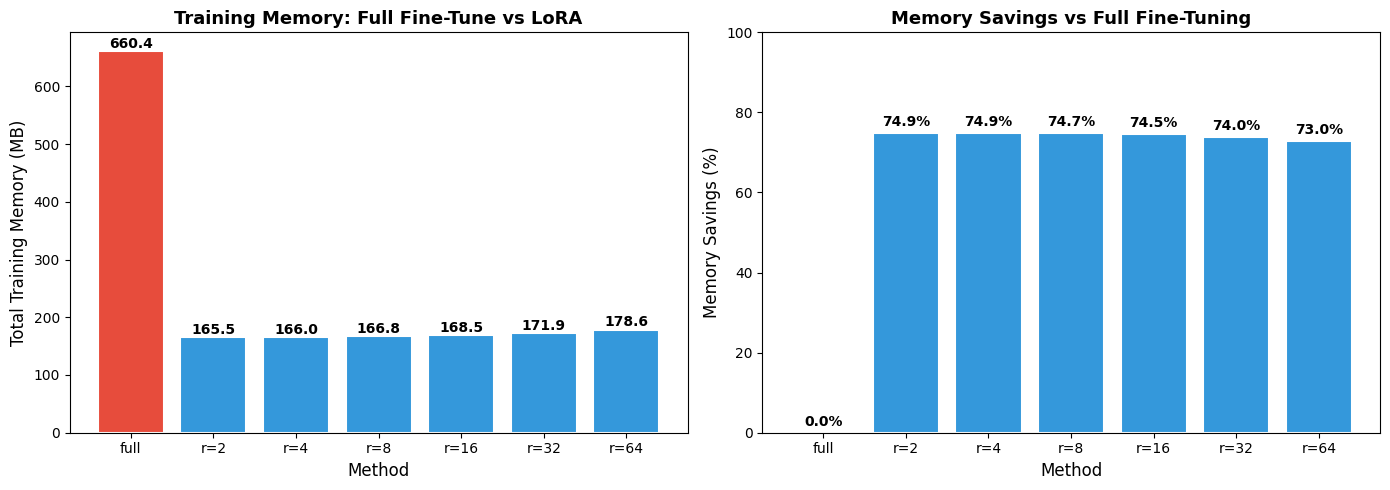


✓ Chart saved as 'lora_memory_comparison.png' — ready for LinkedIn!


In [ ]:
# ──── VISUALIZATION ────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ──── Chart 1: Trainable vs Frozen parameter split ────
ax1 = axes[0]
labels_pie = ['Frozen (original W)', 'Trainable (LoRA A+B)']
sizes = [frozen, trainable]
colors_pie = ['#95a5a6', '#3498db']
explode = (0, 0.08)

wedges, texts, autotexts = ax1.pie(
    sizes, explode=explode, labels=labels_pie, colors=colors_pie,
    autopct=lambda p: f'{p:.1f}%\n({int(p*total/100):,})',
    startangle=90, textprops={'fontsize': 10}
)
autotexts[1].set_fontweight('bold')
ax1.set_title('Parameter Split After LoRA Injection', fontsize=12, fontweight='bold')

# ──── Chart 2: Training memory breakdown (weights + grads + optimizer) ────
ax2 = axes[1]
bytes_per_param = 4  # float32

# Full fine-tune: weights + grads + Adam (2 states)
full_weights_mb = total * bytes_per_param / 1024**2
full_grads_mb = total * bytes_per_param / 1024**2
full_optim_mb = total * bytes_per_param * 2 / 1024**2
full_total_mb = full_weights_mb + full_grads_mb + full_optim_mb

# LoRA: weights (all stored) + grads (only LoRA) + Adam (only LoRA)
lora_weights_mb = total * bytes_per_param / 1024**2
lora_grads_mb = trainable * bytes_per_param / 1024**2
lora_optim_mb = trainable * bytes_per_param * 2 / 1024**2
lora_total_mb = lora_weights_mb + lora_grads_mb + lora_optim_mb

x_pos = [0, 1]
bar_width = 0.6

# Stacked bars
b1 = ax2.bar(x_pos, [full_weights_mb, lora_weights_mb], bar_width, label='Weights', color='#3498db')
b2 = ax2.bar(x_pos, [full_grads_mb, lora_grads_mb], bar_width, bottom=[full_weights_mb, lora_weights_mb], label='Gradients', color='#e74c3c')
b3 = ax2.bar(x_pos, [full_optim_mb, lora_optim_mb], bar_width,
             bottom=[full_weights_mb + full_grads_mb, lora_weights_mb + lora_grads_mb],
             label='Optimizer (Adam)', color='#f39c12')

ax2.set_xticks(x_pos)
ax2.set_xticklabels(['Full Fine-Tune', 'LoRA (r=8)'], fontsize=11)
ax2.set_ylabel('Memory (MB)', fontsize=11)
ax2.set_title('Training Memory Breakdown', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)

# Annotate totals
for i, tot in enumerate([full_total_mb, lora_total_mb]):
    ax2.text(i, tot + 5, f'{tot:.1f} MB', ha='center', va='bottom', fontsize=11, fontweight='bold')

saving_pct = (1 - lora_total_mb / full_total_mb) * 100
ax2.text(0.5, full_total_mb * 0.5, f'↓ {saving_pct:.0f}% saved', ha='center',
         fontsize=13, fontweight='bold', color='#27ae60',
         transform=ax2.get_xaxis_transform())

# ──── Chart 3: LoRA params by rank sweep ────
ax3 = axes[2]
ranks = [1, 2, 4, 8, 16, 32, 64]
n_target_layers = 12  # 6 layers × 2 (q_proj + v_proj)
d = 768

lora_params_by_rank = [2 * r * d * n_target_layers for r in ranks]
pct_by_rank = [lp / total * 100 for lp in lora_params_by_rank]

bars = ax3.bar([str(r) for r in ranks], pct_by_rank, color='#3498db', edgecolor='white', linewidth=1.5)
ax3.axhline(y=100, color='#e74c3c', linestyle='--', linewidth=1.5, label='Full fine-tune (100%)')

# Highlight the r=8 bar (what we used)
bars[3].set_color('#2ecc71')
bars[3].set_edgecolor('#27ae60')

for bar, pct, lp in zip(bars, pct_by_rank, lora_params_by_rank):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax3.set_xlabel('LoRA Rank (r)', fontsize=11)
ax3.set_ylabel('Trainable Params (% of full model)', fontsize=11)
ax3.set_title('Trainable % vs LoRA Rank', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)

plt.tight_layout()
plt.savefig('lora_memory_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved as 'lora_memory_comparison.png'")

---
## Step 6: Actually Train with LoRA

Let's do a real training loop to prove it works.  
We'll train on a simple task: learn a linear mapping from random inputs to random targets.

In [11]:
# ──── Create a fresh model and inject LoRA ────

model = MiniTransformer(n_layers=2, d_model=256).to(device)
model = inject_lora(model, target_layer_names=['q_proj', 'v_proj'], r=4, alpha=8)

# ──── Verify: which parameters will be trained? ────

print("\nTrainable parameters:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"  ✓ {name}: {param.shape}")

print("\nFrozen parameters (first 5):")
for i, (name, param) in enumerate(model.named_parameters()):
    if not param.requires_grad:
        print(f"  ✗ {name}: {param.shape}")
    if i > 10:
        print("  ...")
        break

  ✓ Injected LoRA into: layers.0.q_proj (shape: torch.Size([256, 256]))
  ✓ Injected LoRA into: layers.0.v_proj (shape: torch.Size([256, 256]))
  ✓ Injected LoRA into: layers.1.q_proj (shape: torch.Size([256, 256]))
  ✓ Injected LoRA into: layers.1.v_proj (shape: torch.Size([256, 256]))

Trainable parameters:
  ✓ layers.0.q_proj.A: torch.Size([4, 256])
  ✓ layers.0.q_proj.B: torch.Size([256, 4])
  ✓ layers.0.k_proj.weight: torch.Size([256, 256])
  ✓ layers.0.k_proj.bias: torch.Size([256])
  ✓ layers.0.v_proj.A: torch.Size([4, 256])
  ✓ layers.0.v_proj.B: torch.Size([256, 4])
  ✓ layers.0.o_proj.weight: torch.Size([256, 256])
  ✓ layers.0.o_proj.bias: torch.Size([256])
  ✓ layers.0.ff_up.weight: torch.Size([1024, 256])
  ✓ layers.0.ff_up.bias: torch.Size([1024])
  ✓ layers.0.ff_down.weight: torch.Size([256, 1024])
  ✓ layers.0.ff_down.bias: torch.Size([256])
  ✓ layers.1.q_proj.A: torch.Size([4, 256])
  ✓ layers.1.q_proj.B: torch.Size([256, 4])
  ✓ layers.1.k_proj.weight: torch.Size([25

In [13]:
print(X.device)
print(next(model.parameters()).device)

cuda:0
cpu


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

optimizer = torch.optim.Adam(
    [p for p in model.parameters() if p.requires_grad],
    lr=1e-3
)

criterion = nn.MSELoss()

torch.manual_seed(42)

X = torch.randn(64, 10, 256).to(device)
Y = torch.randn(64, 10, 1000).to(device)

losses = []

print("Training with LoRA (only A and B matrices update)...\n")

for epoch in range(50):

    optimizer.zero_grad()

    output = model(X)

    loss = criterion(output, Y)

    loss.backward()

    optimizer.step()

    losses.append(loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} Loss: {loss.item():.6f}")

print(f"\nFinal Loss: {losses[-1]:.6f}")

Training with LoRA (only A and B matrices update)...

Epoch   0 Loss: 1.001317
Epoch  10 Loss: 0.983678
Epoch  20 Loss: 0.950553
Epoch  30 Loss: 0.912568
Epoch  40 Loss: 0.864656

Final Loss: 0.807620


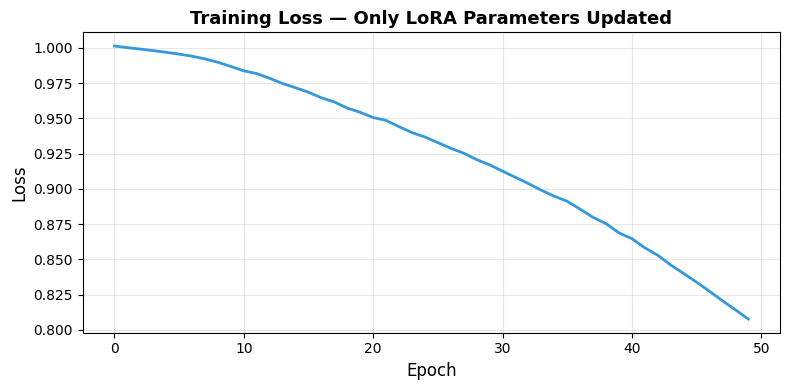


Verification: Did the original (frozen) weights change?
  ✓ No frozen weights have gradients. The original model is untouched.


In [15]:
# ──── Plot training loss ────

plt.figure(figsize=(8, 4))
plt.plot(losses, linewidth=2, color='#3498db')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training Loss — Only LoRA Parameters Updated', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Verify original weights didn't change
print("\nVerification: Did the original (frozen) weights change?")
for name, param in model.named_parameters():
    if not param.requires_grad and param.grad is not None:
        print(f"  BUG! {name} has gradients!")
        break
else:
    print("  ✓ No frozen weights have gradients. The original model is untouched.")

---
## Step 7: Merge LoRA Weights for Deployment

After training, you can **merge** the LoRA matrices back into the original weights.  
This means:
- No extra computation at inference time
- The merged model is exactly the same size as the original
- You can save/share just the tiny LoRA weights separately

In [16]:
def merge_and_compare(model):
    """Merge LoRA weights and verify the output doesn't change."""
    
    # Test input
    x = torch.randn(1, 5, 256).to(device)
    
    # Output BEFORE merging (LoRA adds correction at runtime)
    with torch.no_grad():
        output_before = model(x).clone()
    
    # Merge LoRA into original weights
    for name, module in model.named_modules():
        if isinstance(module, LoRALinear):
            # W_new = W_original + scaling * B @ A
            merged = module.merge_weights()
            
            # Replace LoRALinear with the merged nn.Linear
            parts = name.split('.')
            parent = model
            for part in parts[:-1]:
                parent = getattr(parent, part)
            setattr(parent, parts[-1], merged)
            print(f"  ✓ Merged: {name}")
    
    # Output AFTER merging (correction is baked into weights)
    with torch.no_grad():
        output_after = model(x)
    
    diff = (output_before - output_after).abs().max().item()
    print(f"\nMax difference before vs after merge: {diff:.10f}")
    print(f"(Should be ~0, any tiny difference is floating point noise)")
    
    # Now the model has NO LoRA layers — it's a plain nn.Module
    has_lora = any(isinstance(m, LoRALinear) for m in model.modules())
    print(f"\nModel still has LoRA layers? {has_lora}")
    print(f"✓ Model is now a plain PyTorch model — ready for deployment!")
    
    return model

merged_model = merge_and_compare(model)

  ✓ Merged: layers.0.q_proj
  ✓ Merged: layers.0.v_proj
  ✓ Merged: layers.1.q_proj
  ✓ Merged: layers.1.v_proj

Max difference before vs after merge: 0.0000004619
(Should be ~0, any tiny difference is floating point noise)

Model still has LoRA layers? False
✓ Model is now a plain PyTorch model — ready for deployment!


---
## Step 8: Save & Load Just the LoRA Weights

The whole point of LoRA is portability: the adapter weights are tiny.

In [17]:
import os

def save_lora_weights(model, path):
    """Save only the LoRA (trainable) parameters."""
    lora_state = {}
    for name, param in model.named_parameters():
        if param.requires_grad:  # Only LoRA params
            lora_state[name] = param.data.clone()
    
    torch.save(lora_state, path)
    
    file_size = os.path.getsize(path)
    print(f"Saved {len(lora_state)} LoRA parameter tensors")
    print(f"File size: {file_size / 1024:.1f} KB")
    return lora_state

def load_lora_weights(model, path):
    """Load LoRA weights back into a LoRA-injected model."""
    lora_state = torch.load(path, weights_only=True)
    
    for name, param in model.named_parameters():
        if name in lora_state:
            param.data.copy_(lora_state[name])
    
    print(f"Loaded {len(lora_state)} LoRA parameter tensors")

# Demo: create a new model, inject LoRA, and save
demo_model = MiniTransformer(n_layers=2, d_model=256).to(device)
demo_model = inject_lora(demo_model, ['q_proj', 'v_proj'], r=4, alpha=8)

# Simulate some training by randomizing LoRA weights
for name, param in demo_model.named_parameters():
    if param.requires_grad:
        param.data.normal_(0, 0.1)

print("\n── Saving LoRA weights ──")
save_lora_weights(demo_model, 'lora_adapter.pt')

# Compare to full model size
full_state = {n: p.data for n, p in demo_model.named_parameters()}
torch.save(full_state, 'full_model.pt')
full_size = os.path.getsize('full_model.pt')
lora_size = os.path.getsize('lora_adapter.pt')

print(f"\n── Size Comparison ──")
print(f"Full model:    {full_size / 1024:.1f} KB")
print(f"LoRA adapter:  {lora_size / 1024:.1f} KB")
print(f"Ratio:         {full_size / lora_size:.1f}x smaller")

# Cleanup
os.remove('lora_adapter.pt')
os.remove('full_model.pt')

  ✓ Injected LoRA into: layers.0.q_proj (shape: torch.Size([256, 256]))
  ✓ Injected LoRA into: layers.0.v_proj (shape: torch.Size([256, 256]))
  ✓ Injected LoRA into: layers.1.q_proj (shape: torch.Size([256, 256]))
  ✓ Injected LoRA into: layers.1.v_proj (shape: torch.Size([256, 256]))

── Saving LoRA weights ──
Saved 26 LoRA parameter tensors
File size: 6178.4 KB

── Size Comparison ──
Full model:    7208.9 KB
LoRA adapter:  6178.4 KB
Ratio:         1.2x smaller


---
## Step 9: Scale it Up — What This Looks Like on Real Models

Let's compute the numbers for models at different scales.

In [18]:
# ──── Scale Analysis ────

print(f"{'Model Size':<15} {'Total Params':>15} {'LoRA r=8':>15} {'LoRA %':>10} {'Full FT Memory':>15} {'LoRA Memory':>15} {'Savings':>10}")
print(f"{'─'*95}")

configs = [
    ("125M (GPT-2)",   768,  12),
    ("350M",          1024,  24),
    ("1.3B",          2048,  24),
    ("7B (LLaMA)",    4096,  32),
    ("13B",           5120,  40),
    ("70B (LLaMA-2)", 8192,  80),
]

scale_data = []

for label, d_model, n_layers in configs:
    # Rough param count (attention + FFN)
    params_per_layer = 4 * d_model**2 + 2 * d_model * (4 * d_model)  # attn + ffn
    total = params_per_layer * n_layers
    
    r = 8
    lora_per_layer = 2 * (2 * r * d_model)  # q_proj + v_proj, each has A+B
    lora_total = lora_per_layer * n_layers
    lora_pct = lora_total / total * 100
    
    # Memory: weights + gradients + optimizer (Adam = 2x)
    full_mem = total * 4 * 4 / 1024**3   # weights + grads + 2x optimizer, in GB
    lora_mem = (total * 4 + lora_total * 4 * 3) / 1024**3  # weights + lora(grads+optim)
    savings = (1 - lora_mem / full_mem) * 100
    
    scale_data.append((label, total, lora_total, full_mem, lora_mem, savings))
    
    def fmt(n):
        if n >= 1e9: return f"{n/1e9:.1f}B"
        if n >= 1e6: return f"{n/1e6:.0f}M"
        return f"{n/1e3:.0f}K"
    
    print(f"{label:<15} {fmt(total):>15} {fmt(lora_total):>15} {lora_pct:>9.2f}% {full_mem:>13.1f}GB {lora_mem:>13.1f}GB {savings:>9.1f}%")

Model Size         Total Params        LoRA r=8     LoRA %  Full FT Memory     LoRA Memory    Savings
───────────────────────────────────────────────────────────────────────────────────────────────
125M (GPT-2)                85M            295K      0.35%           1.3GB           0.3GB      74.7%
350M                       302M            786K      0.26%           4.5GB           1.1GB      74.8%
1.3B                       1.2B              2M      0.13%          18.0GB           4.5GB      74.9%
7B (LLaMA)                 6.4B              4M      0.07%          96.0GB          24.0GB      75.0%
13B                       12.6B              7M      0.05%         187.5GB          46.9GB      75.0%
70B (LLaMA-2)             64.4B             21M      0.03%         960.0GB         240.2GB      75.0%


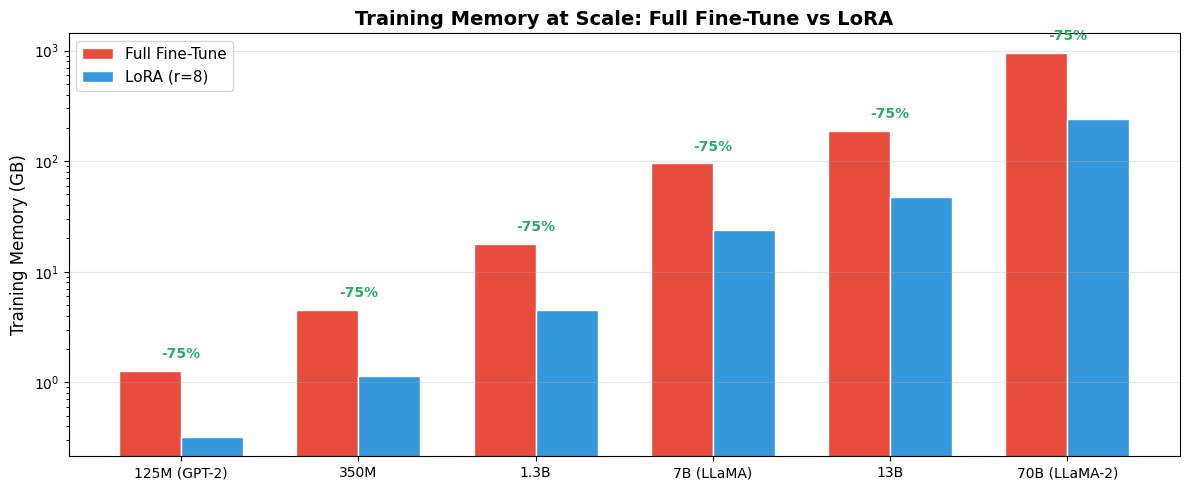

✓ Chart saved as 'lora_scale_comparison.png'


In [19]:
# ──── Final Visualization: Scale Chart ────

fig, ax = plt.subplots(figsize=(12, 5))

labels = [d[0] for d in scale_data]
full_mems = [d[3] for d in scale_data]
lora_mems = [d[4] for d in scale_data]

x = range(len(labels))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], full_mems, width, label='Full Fine-Tune', color='#e74c3c', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], lora_mems, width, label='LoRA (r=8)', color='#3498db', edgecolor='white')

ax.set_ylabel('Training Memory (GB)', fontsize=12)
ax.set_title('Training Memory at Scale: Full Fine-Tune vs LoRA', fontsize=14, fontweight='bold')
ax.set_xticks(list(x))
ax.set_xticklabels(labels, fontsize=10)
ax.legend(fontsize=11)
ax.set_yscale('log')  # Log scale because 70B is massive
ax.grid(True, alpha=0.3, axis='y')

# Add savings labels
for i, (f, l) in enumerate(zip(full_mems, lora_mems)):
    saving = (1 - l/f) * 100
    ax.text(i, max(f, l) * 1.3, f'-{saving:.0f}%', ha='center', fontsize=10, fontweight='bold', color='#27ae60')

plt.tight_layout()
plt.savefig('lora_scale_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved as 'lora_scale_comparison.png'")

---
## Summary: What We Built

| Component | What it does | Lines of code |
|-----------|-------------|---------------|
| `LoRALinear` | Wraps any `nn.Linear` with trainable low-rank matrices A and B | ~30 |
| `inject_lora()` | Walks a model and replaces target layers with LoRA versions | ~15 |
| `merge_weights()` | Bakes LoRA correction into the original weight matrix | ~3 |
| `save/load_lora_weights()` | Saves only the tiny adapter weights | ~10 |

### Key Takeaways for Startups

1. **LoRA cuts training memory by 60-75%** — the difference between needing an A100 and getting by with a T4
2. **The math is simple**: just two small matrices multiplied together, added to the frozen weights
3. **Zero inference overhead** after merging — your production model runs at the same speed
4. **Adapters are tiny** (~1-5% of full model) — easy to version, store, and swap
5. **No loss at initialization** — B starts at zero, so training begins from the exact pretrained behavior

### The Core Equation

$$y = \left(W + \frac{\alpha}{r} \cdot B \times A\right) \cdot x$$

Where $W$ is frozen, and only $A$ (`r × d_in`) and $B$ (`d_out × r`) are trained.

---

*Next up: Apply this to a real LLM (TinyLlama) — see `finetuning_using_lora_peft.ipynb` for the HuggingFace version.*